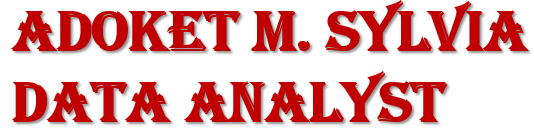

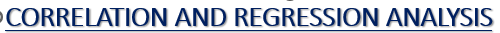


## (a). **Pearson Correlation Analysis**

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

## Sample data frame

Ho: No association between age and weight
H1: There is association between age and weight

In [40]:
data = pd.DataFrame({
    'Age': [33, 40, 35, 43, 44, 23, 34, 54, 33],
    'Weight': [67, 77, 69, 71, 70, 65, 65, 89, 75]
})
data

,Age,Weight
0,33,67
1,40,77
2,35,69
3,43,71
4,44,70
5,23,65
6,34,65
7,54,89
8,33,75


In [41]:
r, p_value = pearsonr(data["Age"], data["Weight"])
print(f"Pearson correlation coefficient:{r:.3f}")
print(f"p-value:{p_value:.3f}")

Pearson correlation coefficient:0.781
p-value:0.013


Since p-value is less tha 0.05, we reject null hypothesis and conclude that there is strong positive significant relationship between age and weight.

In [42]:
data.corr()

,Age,Weight
Age,1.000000,0.780839
Weight,0.780839,1.000000


## Spearman correlation

In [43]:
spearman_corr, spearman_p = spearmanr(data["Age"], data["Weight"])
print(f"Spearman Correlation:{spearman_corr:.3f}, p-value: {spearman_p:.3f}")

Spearman Correlation:0.647, p-value: 0.060


In [44]:
r = data['Age'].corr(data['Weight'])
print(f"Pearson correlation coefficient:{r:4f}")

Pearson correlation coefficient:0.780839


## Correlation Heatmap

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

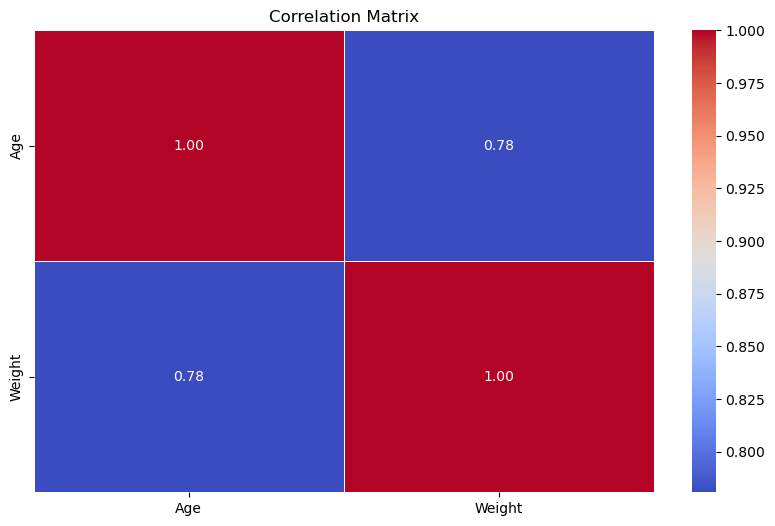

In [46]:
corr_matrix = data.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

 ## **Simple Linear Regression Model**

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
data2 = pd.DataFrame({
    'Rainfall': [80, 100, 12.0, 140, 160],
    'Malaria_Cases': [30, 40, 50, 60, 70]
})

x = data2[['Rainfall']]
y = data2['Malaria_Cases']

model = LinearRegression()
model.fit(x,y)

print("Intercept:", model.intercept_)
print("Slope (Rainfall):", model.coef_[0])

y_pred = model.predict(x)
print("Predicted values:", y_pred)

Intercept: -10.0
Slope (Rainfall): 0.5
Predicted values: [30. 40. 50. 60. 70.]


In [49]:
data = pd.DataFrame({
    'Age': [33, 40, 35, 43, 44, 23, 34, 54, 33],
    'Weight': [67, 77, 69, 71, 70, 65, 65, 89, 75]
})


In [50]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
data

x = sm.add_constant(data['Age'])
y = data['Weight']

model = sm.OLS(y,x).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     10.94
Date:                Thu, 14 May 2026   Prob (F-statistic):             0.0130
Time:                        11:38:57   Log-Likelihood:                -26.240
No. Observations:                   9   AIC:                             56.48
Df Residuals:                       7   BIC:                             56.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.6661      7.845      5.949      0.0

# **Multiple Linear Regression Model**

In [51]:
gss=pd.read_csv("GSSsubset.csv")
gss.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


In [61]:
miss_values=gss.isnull().sum()
miss_values

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

In [53]:
x=gss[["age","height","weight","hrswrk"]]
y=gss["income"]

x = x.fillna(x.mean())

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     62.13
Date:                Thu, 14 May 2026   Prob (F-statistic):           7.23e-47
Time:                        11:38:59   Log-Likelihood:                -11690.
No. Observations:                 994   AIC:                         2.339e+04
Df Residuals:                     989   BIC:                         2.342e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.325e+05   1.73e+04     -7.668      0.0

## **Testing the Assumptions of Classical Linear Regression Models**
### 1. A plot of Residuals vs Fitted

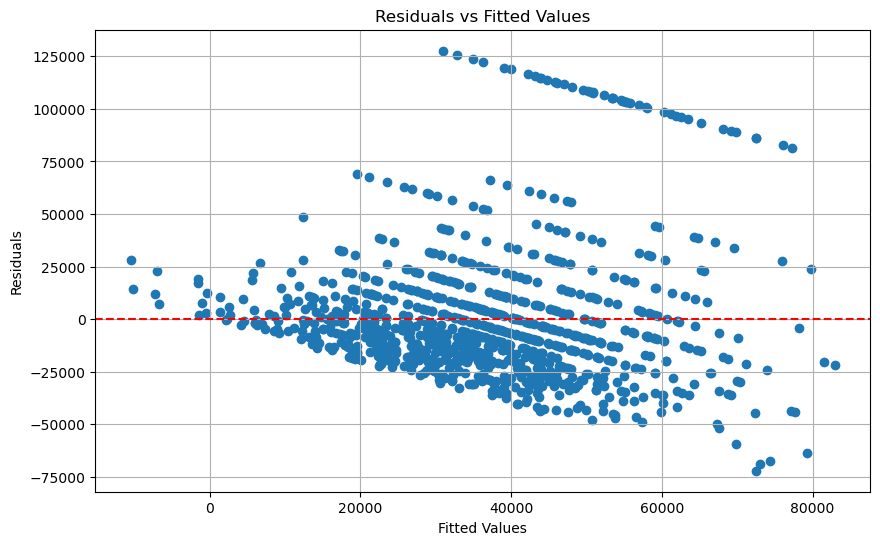

In [54]:
residuals = model.resid

plt.figure(figsize=(10, 6))
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)
plt.show()

### 2.Multicollinearity Check(VIF):

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

vif_data

,Variable,VIF
0,const,307.265385
1,age,1.005752
2,height,1.331098
3,weight,1.324937
4,hrswrk,1.065460


### 3.Normality of Regression Residuals

In [56]:
Residuals = model.resid
x['Residuals'] = Residuals
x.head(5)

,const,age,height,weight,hrswrk,Residuals
0,1.0,53,72,190,60,-1013.998380
1,1.0,26,60,97,40,48640.590606
2,1.0,56,68,160,20,-17557.974641
3,1.0,40,65,156,37,-8691.723951
4,1.0,56,66,210,6,3475.303243


## **Histogram Showing the Distribution of the Residuals**

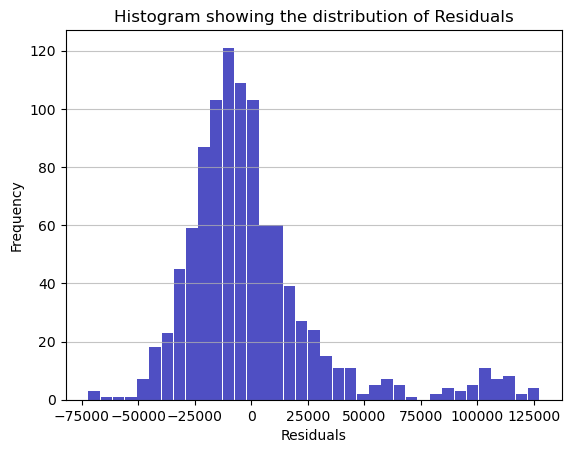

In [57]:
n, bins, patches = plt.hist(x=Residuals, bins='auto', color='#0504aa',
                           alpha=0.7, rwidth=0.95)
plt.grid(axis='y', alpha=0.75)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram showing the distribution of Residuals')
plt.show()

## **ASSIGNMENT**

In [98]:
mtcars=pd.read_csv("mtcars.csv")
mtcars.head()

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,36945.0,33337.0,3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820.0,21761.0,2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,26990.0,24647.0,2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,33195.0,30299.0,3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,43755.0,39014.0,3.5,6.0,225,18,24,3880,115,197


In [99]:
miss_values=mtcars.isnull().sum()
miss_values

Make           0
Model          0
Type           0
Origin         0
DriveTrain     0
MSRP           0
Invoice        0
EngineSize     0
Cylinders      2
Horsepower     0
MPG_City       0
MPG_Highway    0
Weight         0
Wheelbase      0
Length         0
dtype: int64

In [100]:
mtcars.dropna(inplace=True)
missing_values=mtcars.isnull().sum()
missing_values

Make           0
Model          0
Type           0
Origin         0
DriveTrain     0
MSRP           0
Invoice        0
EngineSize     0
Cylinders      0
Horsepower     0
MPG_City       0
MPG_Highway    0
Weight         0
Wheelbase      0
Length         0
dtype: int64

Ho: No association between age and weight
H1: There is association between age and weight

In [101]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

mtcars_sub = pd.DataFrame(mtcars[['Horsepower', 'Cylinders']])
mtcars_sub

,Horsepower,Cylinders
0,265,6.0
1,200,4.0
2,200,4.0
3,270,6.0
4,225,6.0
...,...,...
423,197,5.0
424,242,5.0
425,268,6.0
426,170,4.0


In [102]:
r, p_value = pearsonr(mtcars_sub["Horsepower"], mtcars_sub["Cylinders"])
print(f"Pearson correlation coefficient:{r:.3f}")
print(f"p-value:{p_value:.3f}")

Pearson correlation coefficient:0.810
p-value:0.000


Since p-value is less tha 0.05, we reject null hypothesis and conclude that there is strong positive significant relationship between horsepower and cylinders.

In [103]:
mtcars_sub.corr()

,Horsepower,Cylinders
Horsepower,1.000000,0.810341
Cylinders,0.810341,1.000000


In [104]:
spearman_corr, spearman_p = spearmanr(mtcars_sub["Horsepower"], mtcars_sub["Cylinders"])
print(f"Spearman Correlation:{spearman_corr:.3f}, p-value: {spearman_p:.3f}")

Spearman Correlation:0.815, p-value: 0.000


In [105]:
r = mtcars_sub['Horsepower'].corr(mtcars_sub['Cylinders'])
print(f"Pearson correlation coefficient:{r:4f}")

Pearson correlation coefficient:0.810341


## **Correlation Heatmap**

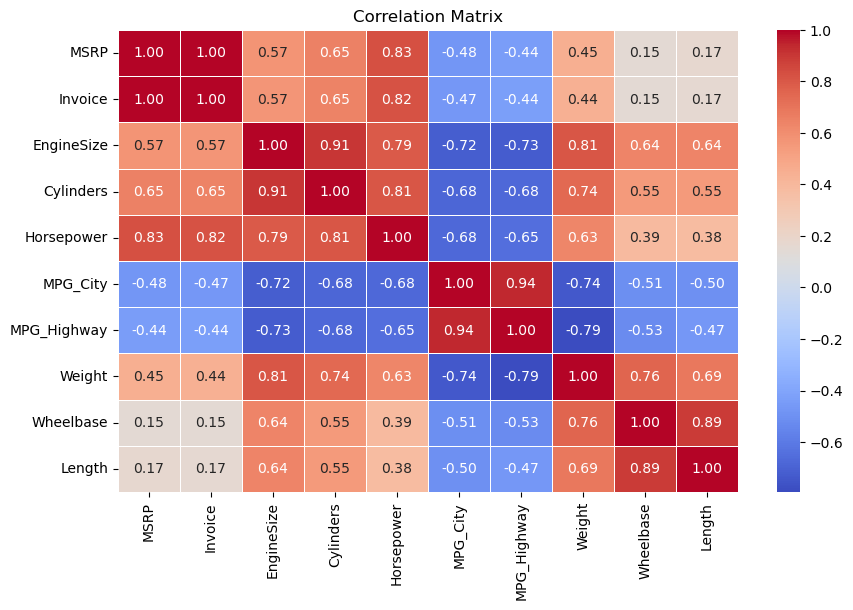

In [106]:
corr_matrix = mtcars.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

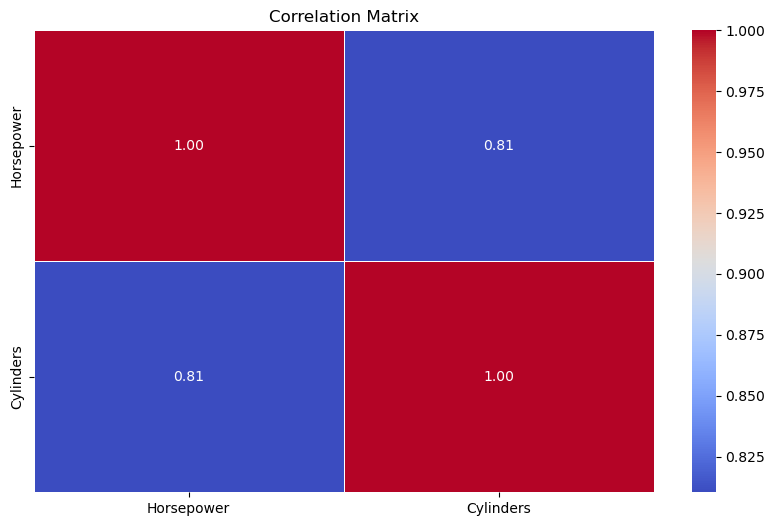

In [107]:
corr_matrix = mtcars_sub.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Simple Linear Regression Model

In [115]:
df2=pd.DataFrame(mtcars[['Horsepower', 'EngineSize']])
df2.head()

,Horsepower,EngineSize
0,265,3.5
1,200,2.0
2,200,2.4
3,270,3.2
4,225,3.5


In [117]:
x = mtcars[['Horsepower']]
y = mtcars['EngineSize']

model = LinearRegression()
model.fit(x,y)

print("Intercept:", model.intercept_)
print("Slope (EgineSize):", model.coef_[0])

y_pred = model.predict(x)
print("Predicted values:", y_pred)

Intercept: 0.5806905446414965
Slope (EgineSize): 0.012159386585867538
Predicted values: [3.80292799 3.01256786 3.01256786 3.86372492 3.31655253 3.31655253
 4.10691265 2.64778626 2.64778626 3.25575559 3.25575559 3.25575559
 3.25575559 3.25575559 3.25575559 3.25575559 3.62053719 4.22850652
 4.59328812 4.71488198 6.05241451 2.76938013 3.31655253 3.62053719
 3.25575559 4.71488198 3.31655253 4.53249119 2.81801768 2.81801768
 2.81801768 2.81801768 3.31655253 3.31655253 3.31655253 2.81801768
 3.31655253 3.31655253 4.53249119 4.53249119 4.53249119 4.62976628
 4.62976628 2.81801768 3.31655253 2.81801768 3.92452186 2.83017706
 2.7085832  3.07336479 3.01256786 3.49894333 3.07336479 3.07336479
 3.49894333 4.16770959 4.47169425 3.68133412 3.92452186 4.22850652
 3.92452186 4.47169425 4.77567892 4.16770959 4.16770959 3.92452186
 2.58698933 1.83310736 1.83310736 2.28300467 2.28300467 2.28300467
 2.76938013 2.3438016  3.01256786 2.76938013 3.01256786 3.49894333
 3.01256786 3.01256786 2.890974   2.83017

In [124]:
x = mtcars[['Invoice']]
y = mtcars['Weight']

model = LinearRegression()
model.fit(x,y)

print("Intercept:", model.intercept_)
print("Slope (EgineSize):", model.coef_[0])

y_pred = model.predict(x)
print("Predicted values:", y_pred)

Intercept: 3009.8887531941723
Slope (EgineSize): 0.018993774488178548
Predicted values: [3643.08421331 3423.21227983 3478.028313   3585.38112641 3750.91187108
 3790.53288466 4528.97284921 3456.39440386 3627.30038671 3557.78317208
 3586.6537093  3606.06534683 3639.13350821 3693.51268457 3737.82516045
 3771.06426581 3747.60695432 3863.39300359 4239.54571356 3837.1815948
 4461.33601826 3627.41434935 3653.60676437 3707.70103412 3713.79803573
 3854.0860541  3653.26487643 3916.27167177 3506.67092493 3546.36791361
 3670.87210538 3536.87102637 3627.66126842 3653.5877706  3657.86136986
 3705.44077495 3779.7064332  3791.86244887 3964.70579671 4210.1053631
 4279.24270224 3848.84377234 3994.0511783  3599.93035767 3723.57982959
 3581.79130303 3662.45786328 3467.35381174 3396.4310578  3471.09558532
 3443.61159363 3504.61959729 3571.45868971 3622.32401779 3711.27186372
 3928.75058161 3836.55480024 3552.63585919 3800.97946063 3890.47812602
 3842.59482053 4349.82356824 3931.86556062 3720.67378209 3699.

In [122]:
x.corr()

,const,Horsepower
const,NaN,NaN
Horsepower,NaN,1.0


In [120]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
mtcars_sub

x = sm.add_constant(mtcars['Horsepower'])
y = mtcars['EngineSize']

model = sm.OLS(y,x).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             EngineSize   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     719.6
Date:                Thu, 14 May 2026   Prob (F-statistic):           2.16e-93
Time:                        13:27:36   Log-Likelihood:                -434.59
No. Observations:                 426   AIC:                             873.2
Df Residuals:                     424   BIC:                             881.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5807      0.103      5.630      0.0

In [121]:
x.corr()

,const,Horsepower
const,NaN,NaN
Horsepower,NaN,1.0


In [123]:
x=mtcars[["Horsepower"]]
y=mtcars["EngineSize"]

x = x.fillna(x.mean())

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             EngineSize   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     719.6
Date:                Thu, 14 May 2026   Prob (F-statistic):           2.16e-93
Time:                        13:38:49   Log-Likelihood:                -434.59
No. Observations:                 426   AIC:                             873.2
Df Residuals:                     424   BIC:                             881.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5807      0.103      5.630      0.0

In [125]:
x=mtcars[["Invoice"]]
y=mtcars["Weight"]

x = x.fillna(x.mean())

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     102.9
Date:                Thu, 14 May 2026   Prob (F-statistic):           8.59e-22
Time:                        13:42:24   Log-Likelihood:                -3383.4
No. Observations:                 426   AIC:                             6771.
Df Residuals:                     424   BIC:                             6779.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3009.8888     65.248     46.130      0.0

## **Testing the Assumptions of Classical Linear Regression Models**
### 1. A plot of Residuals vs Fitted

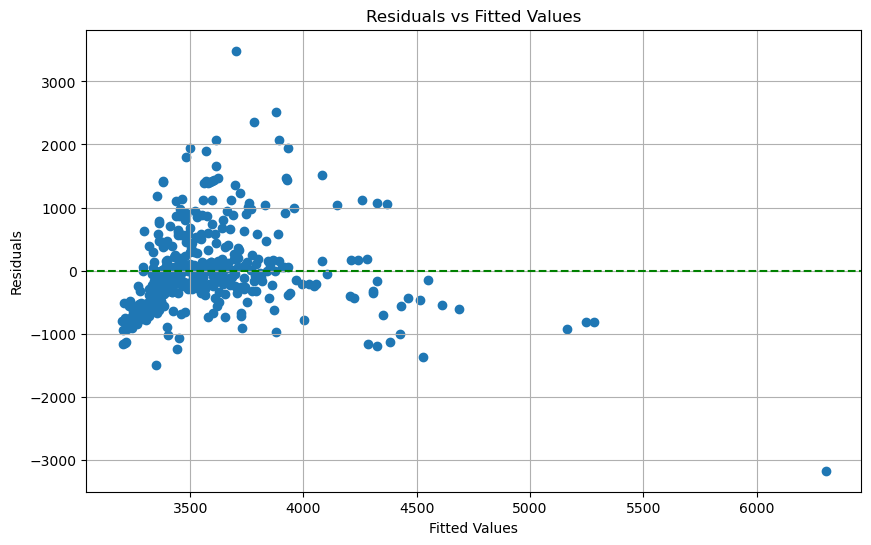

In [126]:
residuals = model.resid

plt.figure(figsize=(10, 6))
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='g', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)
plt.show()

### 2.Multicollinearity Check(VIF):

In [128]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

vif_data

,Variable,VIF
0,const,3.894029
1,Invoice,1.000000


### 3.Normality of Regression Residuals

In [129]:
Residuals = model.resid
x['Residuals'] = Residuals
x.head(5)

,const,Invoice,Residuals
0,1.0,33337.0,807.915787
1,1.0,21761.0,-645.212280
2,1.0,24647.0,-248.028313
3,1.0,30299.0,-10.381126
4,1.0,39014.0,129.088129


## **Histogram Showing the Distribution of the Residuals**

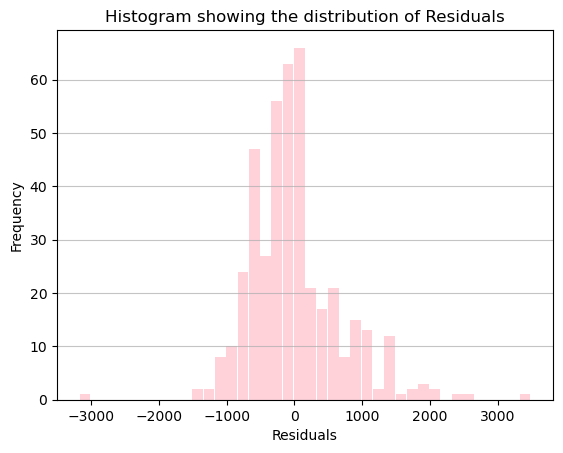

In [134]:
n, bins, patches = plt.hist(x=Residuals, bins='auto', color='pink',
                           alpha=0.7, rwidth=0.95)
plt.grid(axis='y', alpha=0.75)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram showing the distribution of Residuals')
plt.show()